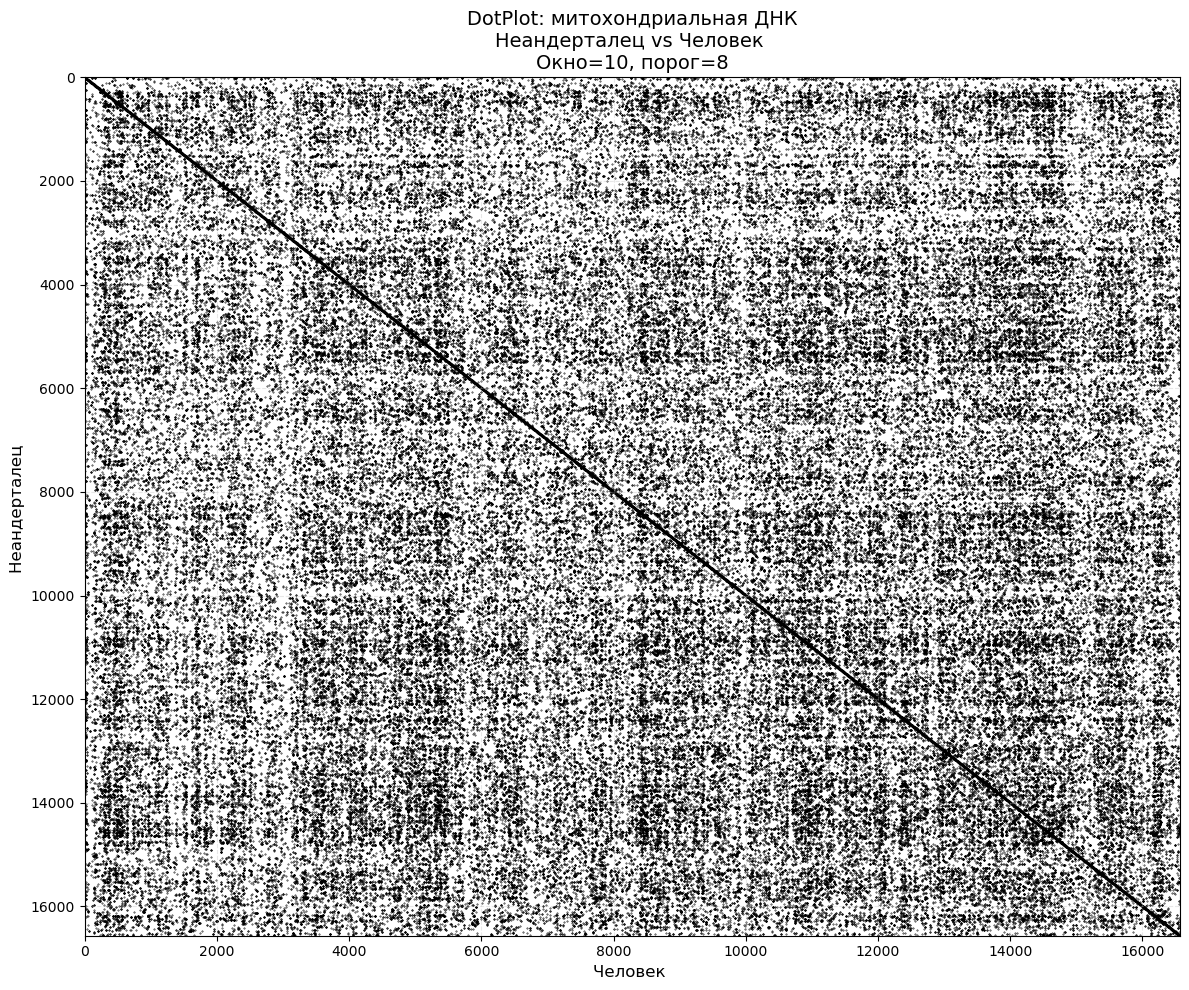


На полученном DotPlot видна четкая непрерывная диагональная линия, что указывает на высокую степень синтении между митохондриальными геномами неандертальца и современного человека. Крупных структурных перестроек, таких как инверсии (обратная диагональ), крупные делеции или дупликации (смещенные или разорванные линии), не наблюдается. Это логично следует из эволюционной близости видов.



In [5]:
import matplotlib.pyplot as plt
from Bio import SeqIO
import numpy as np

# параметры
WINDOW = 10        
THRESHOLD = 8        

neanderthal = SeqIO.read("neander.fasta", "fasta") 
human = SeqIO.read("yung.fasta", "fasta")            
seq1 = str(neanderthal.seq).upper()
seq2 = str(human.seq).upper()
dotplot = np.zeros((len(seq1), len(seq2)), dtype=bool)

for i in range(len(seq1) - WINDOW + 1):
    for j in range(len(seq2) - WINDOW + 1):
        matches = 0
        for k in range(WINDOW):
            if seq1[i + k] == seq2[j + k]:
                matches += 1
        if matches >= THRESHOLD:
            dotplot[i + WINDOW//2, j + WINDOW//2] = True

plt.figure(figsize=(12, 10))
y, x = np.where(dotplot)
plt.scatter(x, y, s=0.5, c='black', marker='.')
plt.xlim(0, len(seq2))
plt.ylim(len(seq1), 0)
plt.xlabel('Человек ', fontsize=12)
plt.ylabel('Неандерталец ', fontsize=12)
plt.title(f'DotPlot: митохондриальная ДНК\nНеандерталец vs Человек \nОкно={WINDOW}, порог={THRESHOLD}', 
          fontsize=14)

plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("""
На полученном DotPlot видна четкая непрерывная диагональная линия, что указывает на высокую степень синтении между митохондриальными геномами неандертальца и современного человека. Крупных структурных перестроек, таких как инверсии (обратная диагональ), крупные делеции или дупликации (смещенные или разорванные линии), не наблюдается. Это логично следует из эволюционной близости видов.
""")